# Saliency Analysis
Loads a single image, runs it through the frozen LinearAE + LossMapClassifier, and produces a 4-panel figure:
**original | reconstruction | loss map | thresholded saliency map**

The saliency map is computed via vanilla gradient backprop through the full pipeline (input → AE → loss map → classifier).
Pixels above the threshold are coloured **red**, below are coloured **green**.

In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore", message="CPyCppyy API not found")

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))

import torch
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from mlflow.tracking import MlflowClient

from dataset import QcdbImageDataset
from utils import load_yaml

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
config    = load_yaml("params.yaml")
cfg       = config["inference_conv_classifier"]
mlflow_cfg = config["mlflow"]

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)

# ── Load models from MLflow ───────────────────────────────────────────────────
mlflow.set_tracking_uri(mlflow_cfg["tracking"]["server_uri"])
client = MlflowClient()

ae_versions = list(client.search_model_versions(f"name='{cfg['ae_model_name']}'"))
latest_ae   = max(ae_versions, key=lambda mv: int(mv.version))
print(f"AE: {cfg['ae_model_name']} v{latest_ae.version}")
ae_model = mlflow.pytorch.load_model(latest_ae.source).to(device)
ae_model.eval()
for p in ae_model.parameters():
    p.requires_grad = False

clf_versions  = list(client.search_model_versions(f"name='{cfg['classifier_model_name']}'"))
latest_clf    = max(clf_versions, key=lambda mv: int(mv.version))
print(f"Classifier: {cfg['classifier_model_name']} v{latest_clf.version}")
classifier = mlflow.pytorch.load_model(latest_clf.source).to(device)
classifier.eval()
for p in classifier.parameters():
    p.requires_grad = False

Loaded .yaml file: /Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/models/autoencoder/params.yaml
Device: mps
AE: LinearAE v3
Classifier: ConvLossMapClassifier v4


In [4]:
# ── Image selection ───────────────────────────────────────────────────────────
IMAGE_FOLDER = os.path.join(cfg["test_data_root"], "transient_effect")  # <-- change class here
SAMPLE_INDEX = 0 # <-- change sample index here
VFLIP        = False    # vertical flip (flip up/down)
HFLIP        = True   # horizontal flip (flip left/right)

image_size = tuple(cfg["image_size"])
ds  = QcdbImageDataset(folder=IMAGE_FOLDER, image_size=image_size)
img = ds[SAMPLE_INDEX]   # [C, H, W] in [0, 1]
if VFLIP:
    img = torch.flip(img, dims=[-2]).contiguous()
if HFLIP:
    img = torch.flip(img, dims=[-1]).contiguous()
print(f"Loaded sample {SAMPLE_INDEX} from '{os.path.basename(IMAGE_FOLDER)}' — shape: {img.shape}, vflip: {VFLIP}, hflip: {HFLIP}")

Loaded sample 0 from 'transient_effect' — shape: torch.Size([3, 330, 330]), vflip: False, hflip: True


In [5]:
# ── Forward pass + saliency ───────────────────────────────────────────────────
# Gradients flow through the frozen AE ops back to the input image.
# AE parameters stay frozen (requires_grad=False), but the computation
# graph is built so d(score)/d(input) can be computed.

img_input = img.unsqueeze(0).to(device)   # [1, C, H, W]
img_input.requires_grad_(True)

recon    = ae_model(img_input)                    # [1, C, H, W]
loss_map = (img_input - recon) ** 2               # [1, C, H, W]
logits   = classifier(loss_map)                   # [1, num_classes]

pred_class = logits.argmax(dim=1).item()
score      = logits[0, pred_class]                # scalar for the predicted class
score.backward()                                  # backprop to img_input

# Collapse channel dim by taking the max absolute gradient across channels → [H, W]
saliency_raw = img_input.grad.abs().squeeze(0).max(dim=0).values
saliency_raw = saliency_raw.detach().cpu()

# Normalise to [0, 1]
sal_min, sal_max = saliency_raw.min(), saliency_raw.max()
saliency_norm = (saliency_raw - sal_min) / (sal_max - sal_min + 1e-8)

FOLDER_TO_LABEL = {
    "good": 0, "empty_histogram": 1, "empty_roc": 2,
    "holes": 3, "transient_effect": 4, "underperforming_region": 5,
}
LABEL_TO_FOLDER = {v: k for k, v in FOLDER_TO_LABEL.items()}
print(f"Predicted class: {LABEL_TO_FOLDER[pred_class]} (index {pred_class})")
print(f"Saliency range before normalisation: [{sal_min:.4e}, {sal_max:.4e}]")

Predicted class: transient_effect (index 4)
Saliency range before normalisation: [2.6552e-06, 7.0870e-01]


Loaded sample 0 from 'transient_effect' — shape: torch.Size([3, 330, 330]), vflip: False, hflip: True
Predicted class: transient_effect (index 4)
Saliency range before normalisation: [2.6552e-06, 7.0870e-01]


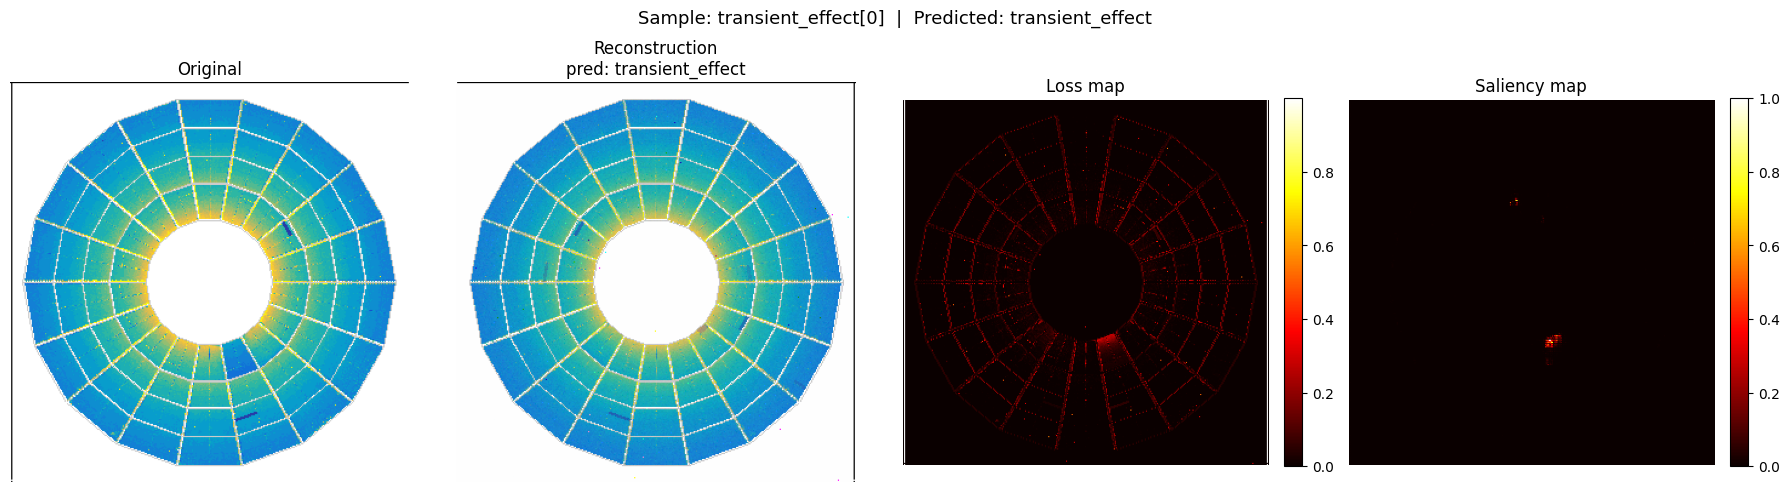

Saved → saliency_transient_effect_0000.png


In [ ]:
# ── Image selection ───────────────────────────────────────────────────────────
IMAGE_FOLDER = os.path.join(cfg["test_data_root"], "transient_effect")  # <-- change class here
SAMPLE_INDEX = 0 # <-- change sample index here
VFLIP        = False    # vertical flip (flip up/down)
HFLIP        = True   # horizontal flip (flip left/right)

image_size = tuple(cfg["image_size"])
ds  = QcdbImageDataset(folder=IMAGE_FOLDER, image_size=image_size)
img = ds[SAMPLE_INDEX]   # [C, H, W] in [0, 1]
if VFLIP:
    img = torch.flip(img, dims=[-2]).contiguous()
if HFLIP:
    img = torch.flip(img, dims=[-1]).contiguous()
print(f"Loaded sample {SAMPLE_INDEX} from '{os.path.basename(IMAGE_FOLDER)}' — shape: {img.shape}, vflip: {VFLIP}, hflip: {HFLIP}")


# ── Forward pass + saliency ───────────────────────────────────────────────────
# Gradients flow through the frozen AE ops back to the input image.
# AE parameters stay frozen (requires_grad=False), but the computation
# graph is built so d(score)/d(input) can be computed.

img_input = img.unsqueeze(0).to(device)   # [1, C, H, W]
img_input.requires_grad_(True)

recon    = ae_model(img_input)                    # [1, C, H, W]
loss_map = (img_input - recon) ** 2               # [1, C, H, W]
logits   = classifier(loss_map)                   # [1, num_classes]

pred_class = logits.argmax(dim=1).item()
score      = logits[0, pred_class]                # scalar for the predicted class
score.backward()                                  # backprop to img_input

# Collapse channel dim by taking the max absolute gradient across channels → [H, W]
saliency_raw = img_input.grad.abs().squeeze(0).max(dim=0).values
saliency_raw = saliency_raw.detach().cpu()

# Normalise to [0, 1]
sal_min, sal_max = saliency_raw.min(), saliency_raw.max()
saliency_norm = (saliency_raw - sal_min) / (sal_max - sal_min + 1e-8)

FOLDER_TO_LABEL = {
    "good": 0, "empty_histogram": 1, "empty_roc": 2,
    "holes": 3, "transient_effect": 4, "underperforming_region": 5,
}
LABEL_TO_FOLDER = {v: k for k, v in FOLDER_TO_LABEL.items()}
print(f"Predicted class: {LABEL_TO_FOLDER[pred_class]} (index {pred_class})")
print(f"Saliency range before normalisation: [{sal_min:.4e}, {sal_max:.4e}]")

# ── Visualisation ─────────────────────────────────────────────────────────────
USE_THRESHOLD      = False   # True → red/green overlay, False → raw heatmap
SALIENCY_THRESHOLD = 0.5     # only used when USE_THRESHOLD = True
SALIENCY_CMAP      = 'hot'   # colormap for the raw heatmap

def to_display(tensor):
    t = tensor.detach().cpu().clamp(0, 1)
    if t.dim() == 3:
        t = t.permute(1, 2, 0)
    return t.numpy()

sal_np    = saliency_norm.numpy()
img_np    = to_display(img)
recon_np  = to_display(recon.squeeze(0))
loss_np   = loss_map.squeeze(0).mean(dim=0).detach().cpu().numpy()
pred_name = LABEL_TO_FOLDER[pred_class]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(img_np)
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(recon_np)
axes[1].set_title(f'Reconstruction\npred: {pred_name}', fontsize=12)
axes[1].axis('off')

im_loss = axes[2].imshow(loss_np, cmap='hot')
axes[2].set_title('Loss map', fontsize=12)
axes[2].axis('off')
fig.colorbar(im_loss, ax=axes[2], fraction=0.046, pad=0.04)

if USE_THRESHOLD:
    sal_rgb = np.zeros((*sal_np.shape, 3), dtype=np.float32)
    sal_rgb[sal_np >= SALIENCY_THRESHOLD] = [1.0, 0.0, 0.0]
    sal_rgb[sal_np <  SALIENCY_THRESHOLD] = [0.0, 0.8, 0.0]
    axes[3].imshow(sal_rgb)
    axes[3].set_title(
        f'Saliency (threshold={SALIENCY_THRESHOLD:.0%})\n'
        f'red ≥ {SALIENCY_THRESHOLD:.0%}  |  green < {SALIENCY_THRESHOLD:.0%}',
        fontsize=12,
    )
else:
    im_sal = axes[3].imshow(sal_np, cmap=SALIENCY_CMAP)
    axes[3].set_title('Saliency map', fontsize=12)
    fig.colorbar(im_sal, ax=axes[3], fraction=0.046, pad=0.04)

axes[3].axis('off')

fig.suptitle(
    f'Sample: {os.path.basename(IMAGE_FOLDER)}[{SAMPLE_INDEX}]  |  Predicted: {pred_name}',
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()

out_path = f'saliency_{os.path.basename(IMAGE_FOLDER)}_{SAMPLE_INDEX:04d}.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'Saved → {out_path}')

Image B: 'holes' sample 0


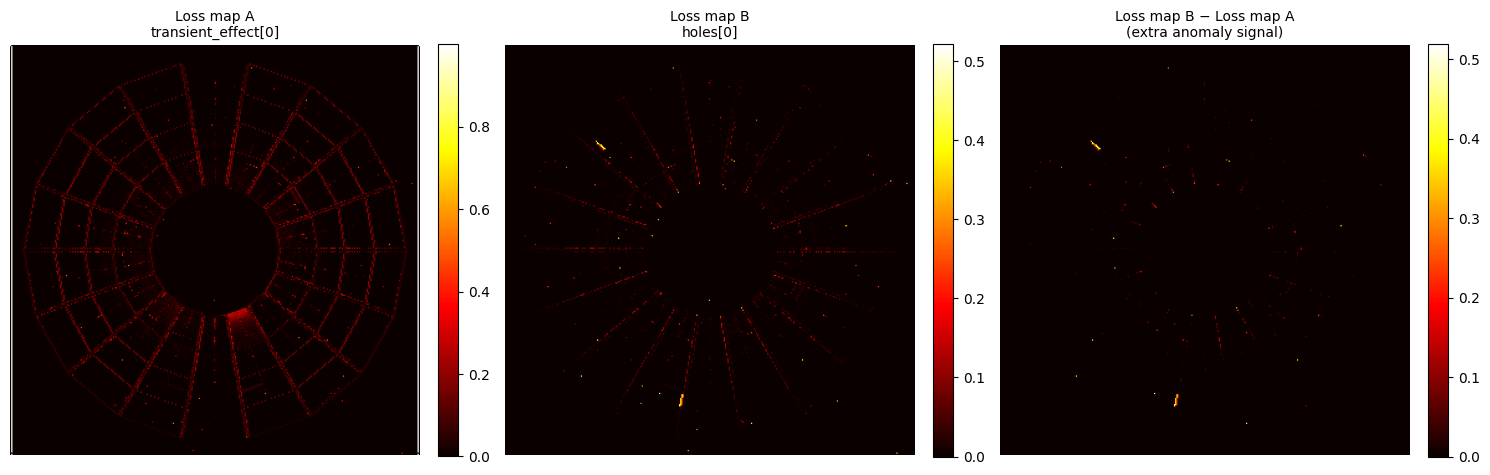

In [7]:
# ── Loss map B minus loss map A ───────────────────────────────────────────────
IMAGE_B_FOLDER = os.path.join(cfg["test_data_root"], "holes")  # <-- folder for image B
IMAGE_B_INDEX  = 0                                              # <-- index for image B

image_size = tuple(cfg["image_size"])
ds_b  = QcdbImageDataset(folder=IMAGE_B_FOLDER, image_size=image_size)
img_b = ds_b[IMAGE_B_INDEX]
print(f"Image B: '{os.path.basename(IMAGE_B_FOLDER)}' sample {IMAGE_B_INDEX}")

# Compute loss map B
with torch.no_grad():
    img_b_input = img_b.unsqueeze(0).to(device)
    recon_b     = ae_model(img_b_input)
    loss_map_b  = (img_b_input - recon_b) ** 2   # [1, C, H, W]

# Collapse to 2D (mean across channels)
loss_2d_a = loss_map.squeeze(0).mean(dim=0).detach().cpu()    # [H, W]
loss_2d_b = loss_map_b.squeeze(0).mean(dim=0).detach().cpu()  # [H, W]

# Subtract A from B — keeps only what's extra in B beyond the detector skeleton
diff = (loss_2d_b - loss_2d_a).clamp(min=0)   # clamp to ignore where A > B

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im_a = axes[0].imshow(loss_2d_a.numpy(), cmap="hot")
axes[0].set_title(f"Loss map A\n{os.path.basename(IMAGE_FOLDER)}[{SAMPLE_INDEX}]", fontsize=10)
axes[0].axis("off")
fig.colorbar(im_a, ax=axes[0], fraction=0.046, pad=0.04)

im_b = axes[1].imshow(loss_2d_b.numpy(), cmap="hot")
axes[1].set_title(f"Loss map B\n{os.path.basename(IMAGE_B_FOLDER)}[{IMAGE_B_INDEX}]", fontsize=10)
axes[1].axis("off")
fig.colorbar(im_b, ax=axes[1], fraction=0.046, pad=0.04)

im_diff = axes[2].imshow(diff.numpy(), cmap="hot")
axes[2].set_title("Loss map B − Loss map A\n(extra anomaly signal)", fontsize=10)
axes[2].axis("off")
fig.colorbar(im_diff, ax=axes[2], fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()

Structural mask ready — 40 views | skeleton pixels: 10890 / 108900 (10.0%)


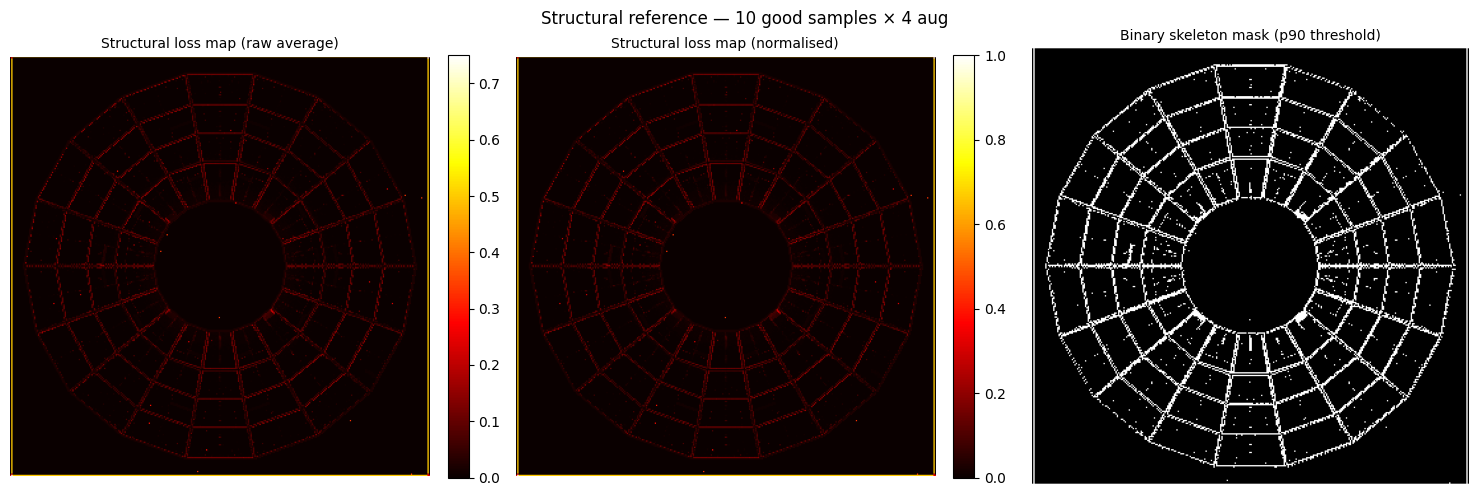

In [ ]:
# ── Structural mask from 1000 good samples ────────────────────────────────────
GOOD_FOLDER_REF = "/Users/zetasourpi/Desktop/GitRepoQC/AIQualityControl/data/tpc/train/rgb_images"
N_REF           = 10
MASK_PERCENTILE = 90   # top X% of structural map -> skeleton -> zeroed out
image_size      = tuple(cfg["image_size"])

ds_ref = QcdbImageDataset(folder=GOOD_FOLDER_REF, image_size=image_size, limit=N_REF)
aug_fns = [
    lambda x: x,
    lambda x: torch.flip(x, dims=[-2]),
    lambda x: torch.flip(x, dims=[-1]),
    lambda x: torch.flip(x, dims=[-2, -1]),
]

acc, count = None, 0
with torch.no_grad():
    for idx in range(len(ds_ref)):
        for aug in aug_fns:
            img_in  = aug(ds_ref[idx]).unsqueeze(0).to(device)
            recon   = ae_model(img_in)
            loss_2d = ((img_in - recon) ** 2).squeeze(0).mean(0).detach().cpu()
            acc     = loss_2d if acc is None else acc + loss_2d
            count  += 1

struct_ref  = acc / count
struct_norm = struct_ref / (struct_ref.max() + 1e-8)
threshold   = torch.quantile(struct_norm, MASK_PERCENTILE / 100)
binary_mask = (struct_norm > threshold).float()
keep_mask   = (1 - binary_mask).to(device)

print(f"Structural mask ready — {count} views | skeleton pixels: {binary_mask.sum().int()} / {binary_mask.numel()} ({binary_mask.mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(struct_ref.numpy(), cmap="hot")
axes[0].set_title("Structural loss map (raw average)", fontsize=10)
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(struct_norm.numpy(), cmap="hot")
axes[1].set_title("Structural loss map (normalised)", fontsize=10)
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(binary_mask.numpy(), cmap="gray")
axes[2].set_title(f"Binary skeleton mask (p{MASK_PERCENTILE} threshold)", fontsize=10)
axes[2].axis("off")

fig.suptitle(f"Structural reference — {len(ds_ref)} good samples × 4 aug", fontsize=12)
fig.tight_layout()
plt.show()